In [ ]:
import marimo as mo

# 🧠 Cerebro en el Frasco
## Material Educativo: Construcción de Agentes con LangChain / LangGraph

Este notebook es una guía práctica completa para entender y construir un **agente
de IA con memoria persistente** usando herramientas modernas del ecosistema Python.

### ¿Qué vas a aprender?

| Módulo | Concepto |
| :--- | :--- |
| **Agentes ReAct** | Ciclo Razonar → Actuar → Observar en LangGraph |
| **Memoria Dual** | Corto plazo (hilo) + Largo plazo (hechos duraderos) en SQLite |
| **Tools** | Cómo declarar herramientas que el LLM puede invocar autónomamente |
| **Middlewares** | Capas de interceptación que modifican el comportamiento del agente |
| **Reflexión Autónoma** | El agente extrae y actualiza hechos sin que el usuario lo pida |
| **Marimo UI** | Dashboard reactivo, panel de control, chat, inspector de memoria |

> **Requisito:** Define `NVIDIA_API_KEY=nvapi-...` en tu archivo `.env` o como
> variable de entorno. Opcionalmente, `TAVILY_API_KEY` para las búsquedas web.

---

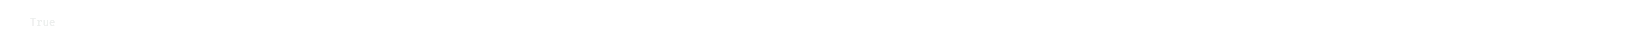

In [ ]:
import os
import sqlite3
import json
import uuid
import datetime
import numpy as np
from pathlib import Path

# ── Utilidades ────────────────────────────────────────────────────────────────────
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing import List, Literal, Optional

# ── Núcleo LangChain / LangGraph ──────────────────────────────────────────────────
from langchain.agents import create_agent
from langchain.tools import tool
from langchain.agents.middleware import (
    dynamic_prompt,
    SummarizationMiddleware,
    ContextEditingMiddleware,
    HumanInTheLoopMiddleware,
    ModelCallLimitMiddleware,
    ToolCallLimitMiddleware,
    ToolRetryMiddleware,
    ModelRetryMiddleware,
    ModelFallbackMiddleware,
    LLMToolSelectorMiddleware,
    TodoListMiddleware,
    PIIMiddleware,
)
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import Item, PutOp

# ── Integración NVIDIA (opcional) ────────────────────────────────────────────────
try:
    from langchain_nvidia_ai_endpoints import ChatNVIDIA, NVIDIAEmbeddings

    PAQUETE_NVIDIA = True
except ImportError:
    PAQUETE_NVIDIA = False
    ChatNVIDIA = NVIDIAEmbeddings = None

# Cargar variables de entorno desde .env (NVIDIA_API_KEY, TAVILY_API_KEY…)
load_dotenv()

In [ ]:
PRESENCIA_API_NVIDIA = bool(
    os.environ.get("NVIDIA_API_KEY", "").startswith("nvapi")
)

# ── Modelos NVIDIA NIM ────────────────────────────────────────────────────────────
MODELO_ESTANDAR = os.environ.get(
    "NIM_MODEL", "nvidia/nemotron-3-ultra-550b-a55b"
)
MODELO_RAZONAMIENTO = os.environ.get(
    "NIM_FALLBACK", "nvidia/nemotron-3-nano-omni-30b-a3b-reasoning"
)
MODELO_EMBEDDINGS = os.environ.get("NIM_EMBED", "nvidia/nv-embedqa-e5-v5")

# ── Identidad del usuario y rutas de persistencia ────────────────────────────────
ID_USUARIO = os.environ.get("CEREBRO_USER", "usuario_principal")

DIRECTORIO_MEMORIA = Path(
    os.environ.get("CEREBRO_DIR", Path.home() / ".memoria_cerebro")
)
DIRECTORIO_MEMORIA.mkdir(parents=True, exist_ok=True)

# Ruta absoluta → nunca depende del cwd (causa #1 de "no me guardó nada" en Windows)
RUTA_BD_LARGO_PLAZO = str(
    (DIRECTORIO_MEMORIA / "memorias_largo_plazo.db").resolve()
)
RUTA_BD_CORTO_PLAZO = str(
    (DIRECTORIO_MEMORIA / "hilos_corto_plazo.db").resolve()
)

---
## ⚙️ Panel de Control del Agente

Ajusta los parámetros del LLM y activa/desactiva middlewares.
Marimo reconstruye el agente y el diagrama de arquitectura **en tiempo real**
cada vez que cambias un valor — sin necesidad de reiniciar nada.

In [ ]:
ui_temperatura = mo.ui.slider(
    start=0.0,
    stop=1.0,
    step=0.05,
    value=0.6,
    label="**Temperatura** — Creatividad / aleatoriedad del modelo",
)
ui_top_p = mo.ui.slider(
    start=0.1,
    stop=1.0,
    step=0.05,
    value=0.95,
    label="**Top-P** — Diversidad del vocabulario (nucleus sampling)",
)
ui_max_tokens = mo.ui.slider(
    start=256,
    stop=65536,
    step=256,
    value=16384,
    label="**Máximo de tokens** — Longitud máxima de la respuesta",
)
ui_reason_budget = mo.ui.slider(
    start=1024,
    stop=32768,
    step=256,
    value=8192,
    label="**Tokens de pensamiento** — Presupuesto para razonamiento interno (CoT)",
)
ui_razonamiento = mo.ui.switch(
    value=True,
    label="🧠 **Habilitar Razonamiento (Chain-of-Thought)** — Usa el modelo de razonamiento",
)

In [ ]:
menu_middlewares = mo.ui.dictionary(
    {
        "resumen_conversacion": mo.ui.switch(
            value=True,
            label="📄 **Resumen Automático** — Condensa historiales largos para no agotar el contexto",
        ),
        "modelo_respaldo": mo.ui.switch(
            value=True,
            label="🔄 **Modelo de Respaldo (Fallback)** — Redirige al modelo secundario si el principal falla",
        ),
        "edicion_contexto": mo.ui.switch(
            value=True,
            label="✂️ **Edición de Contexto** — Poda resultados viejos de herramientas para liberar tokens",
        ),
        "humano_en_bucle": mo.ui.switch(
            value=False,
            label="🙋 **Humano en el Bucle** — Pausa y pide aprobación antes de acciones críticas",
        ),
        "limite_llamadas_modelo": mo.ui.switch(
            value=True,
            label="🛑 **Límite: Llamadas al Modelo** — Previene bucles infinitos (máx. 60/hilo, 25/run)",
        ),
        "limite_llamadas_herramienta": mo.ui.switch(
            value=True,
            label="🛑 **Límite: Herramientas** — Tope de seguridad en invocaciones de tools (máx. 80/hilo)",
        ),
        "reintento_herramienta": mo.ui.switch(
            value=True,
            label="♻️ **Reintento de Herramienta** — Reintenta tools que lanzan excepción (máx. 2 veces)",
        ),
        "reintento_modelo": mo.ui.switch(
            value=True,
            label="♻️ **Reintento del Modelo** — Reintenta el LLM ante errores de red o timeouts",
        ),
        "planificacion_tareas": mo.ui.switch(
            value=True,
            label="📋 **Planificación de Tareas (To-Do)** — Fuerza al modelo a estructurar pasos antes de actuar",
        ),
        "selector_herramientas": mo.ui.switch(
            value=False,
            label="🔍 **Selector Dinámico de Herramientas** — Filtra tools por relevancia (útil con >10 tools)",
        ),
        "censura_datos_personales": mo.ui.switch(
            value=False,
            label="🔒 **Censura PII** — Detecta y enmascara email, URL, IP, teléfono y NSS",
        ),
    }
)

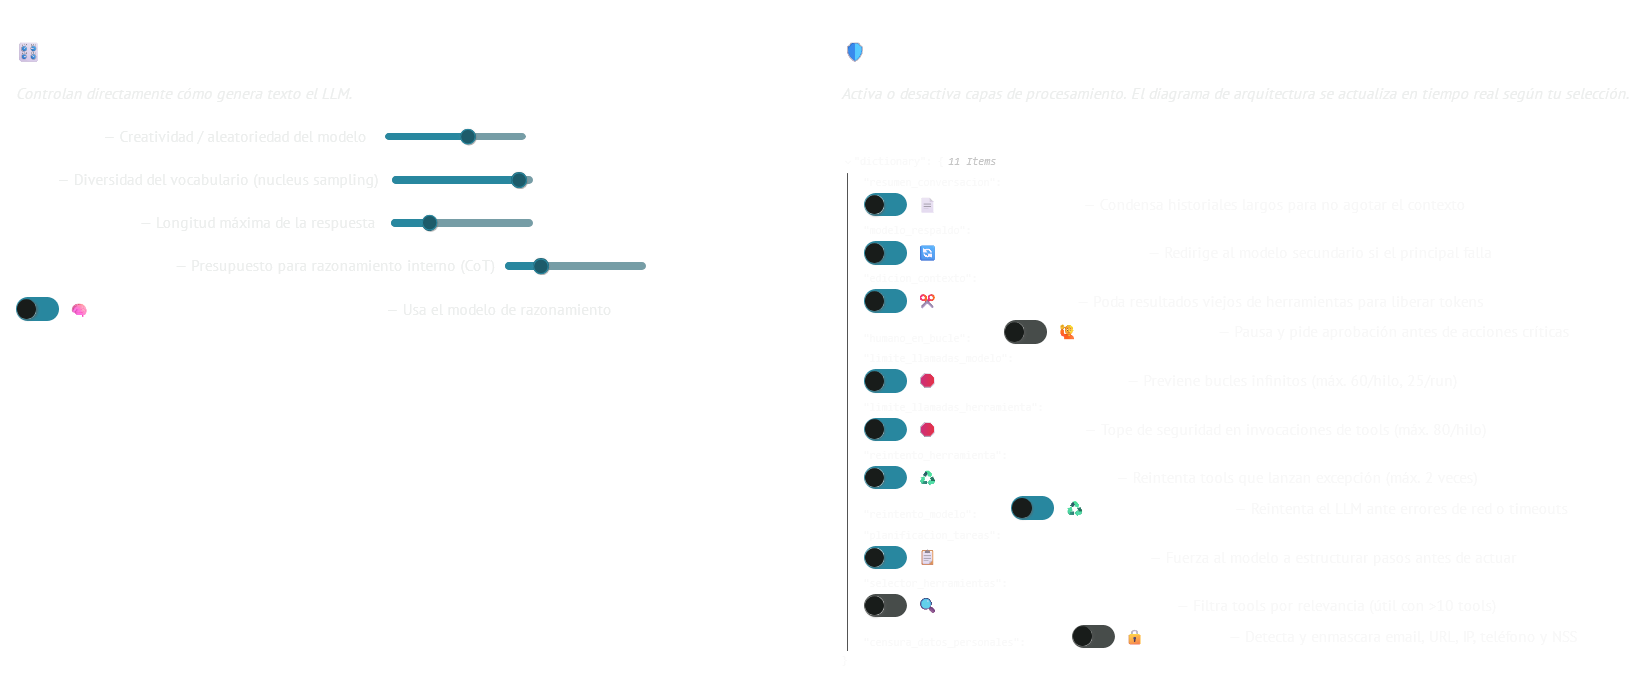

In [ ]:
_panel_llm = mo.md(f"""
### 🎛️ Parámetros del Motor de Inferencia
*Controlan directamente cómo genera texto el LLM.*

{ui_temperatura}

{ui_top_p}

{ui_max_tokens}

{ui_reason_budget}

{ui_razonamiento}
""")

_panel_mw = mo.md(f"""
### 🛡️ Pipeline de Middlewares
*Activa o desactiva capas de procesamiento. El diagrama de arquitectura
se actualiza en tiempo real según tu selección.*

{menu_middlewares}
""")

mo.hstack([_panel_llm, _panel_mw], widths=[1, 1], gap=2)

In [ ]:
class AlmacenPersistenteSQLite(InMemoryStore):
    """Extiende InMemoryStore con persistencia transparente en SQLite.

    Hereda toda la lógica de búsqueda semántica (coseno, ANN) de InMemoryStore
    y añade write-through a disco para que los datos sobrevivan reinicios.
    """

    def __init__(self, ruta_bd: str, *, index=None):
        super().__init__(index=index)
        self._ruta_bd = str(ruta_bd)
        self._conexion = sqlite3.connect(
            self._ruta_bd, check_same_thread=False
        )
        self._conexion.execute("PRAGMA journal_mode=WAL;")
        self._inicializar_esquema()
        self._cargar_datos()

    def _inicializar_esquema(self):
        self._conexion.executescript("""
            CREATE TABLE IF NOT EXISTS store_items(
                namespace      TEXT,
                clave          TEXT,
                valor          TEXT,
                creado_el      TEXT,
                actualizado_el TEXT,
                PRIMARY KEY(namespace, clave)
            );
            CREATE TABLE IF NOT EXISTS store_vectores(
                namespace TEXT,
                clave     TEXT,
                ruta      TEXT,
                vector    BLOB,
                PRIMARY KEY(namespace, clave, ruta)
            );
        """)
        self._conexion.commit()

    @staticmethod
    def _ns_a_str(ns: tuple) -> str:
        return json.dumps(list(ns))

    @staticmethod
    def _str_a_ns(s: str) -> tuple:
        return tuple(json.loads(s))

    def _cargar_datos(self):
        """Carga ítems y vectores desde SQLite al InMemoryStore en RAM al iniciar."""
        for (
            ns_s,
            clave,
            valor,
            creado,
            actualizado,
        ) in self._conexion.execute(
            "SELECT namespace,clave,valor,creado_el,actualizado_el FROM store_items"
        ):
            ns = self._str_a_ns(ns_s)
            self._data[ns][clave] = Item(
                value=json.loads(valor),
                key=clave,
                namespace=ns,
                created_at=creado,
                updated_at=actualizado,
            )
        for ns_s, clave, ruta, blob in self._conexion.execute(
            "SELECT namespace,clave,ruta,vector FROM store_vectores"
        ):
            ns = self._str_a_ns(ns_s)
            self._vectors[ns][clave][ruta] = np.frombuffer(
                blob, dtype=np.float32
            ).tolist()

    def _persistir(self, operaciones):
        """Sincroniza a SQLite las operaciones ya aplicadas en RAM."""
        c = self._conexion
        for op in operaciones:
            if not isinstance(op, PutOp):
                continue
            ns_s = self._ns_a_str(op.namespace)

            if op.value is None:  # borrado
                c.execute(
                    "DELETE FROM store_items WHERE namespace=? AND clave=?",
                    (ns_s, op.key),
                )
                c.execute(
                    "DELETE FROM store_vectores WHERE namespace=? AND clave=?",
                    (ns_s, op.key),
                )
                continue

            item = self._data[op.namespace][op.key]
            c.execute(
                "INSERT OR REPLACE INTO store_items VALUES(?,?,?,?,?)",
                (
                    ns_s,
                    op.key,
                    json.dumps(item.value),
                    str(item.created_at),
                    str(item.updated_at),
                ),
            )
            c.execute(
                "DELETE FROM store_vectores WHERE namespace=? AND clave=?",
                (ns_s, op.key),
            )
            for ruta, vector in (
                self._vectors.get(op.namespace, {}).get(op.key, {}).items()
            ):
                c.execute(
                    "INSERT OR REPLACE INTO store_vectores VALUES(?,?,?,?)",
                    (
                        ns_s,
                        op.key,
                        ruta,
                        np.asarray(vector, dtype=np.float32).tobytes(),
                    ),
                )
        c.commit()

    def batch(self, ops):
        ops = list(ops)
        res = super().batch(ops)  # aplica en RAM + genera embeddings
        self._persistir(ops)  # sincroniza a disco
        return res

    async def abatch(self, ops):
        ops = list(ops)
        res = await super().abatch(ops)
        self._persistir(ops)
        return res

    # ── Métodos de consulta adicionales (SQL directo, sin embeddings) ────────────

    def recientes(self, namespace: tuple, limite: int = 5) -> list[dict]:
        """Devuelve los `limite` ítems más recientemente actualizados."""
        filas = self._conexion.execute(
            "SELECT valor FROM store_items "
            "WHERE namespace=? ORDER BY actualizado_el DESC LIMIT ?",
            (self._ns_a_str(namespace), limite),
        ).fetchall()
        return [json.loads(v) for (v,) in filas]

    def palabra_clave(
        self, namespace: tuple, termino: str, limite: int = 10
    ) -> list[dict]:
        """Búsqueda LIKE sobre el valor JSON serializado (case-insensitive)."""
        filas = self._conexion.execute(
            "SELECT valor FROM store_items "
            "WHERE namespace=? AND lower(valor) LIKE ? "
            "ORDER BY actualizado_el DESC LIMIT ?",
            (self._ns_a_str(namespace), f"%{termino.lower()}%", limite),
        ).fetchall()
        return [json.loads(v) for (v,) in filas]

In [ ]:
ESPACIO_MEMORIA = ("memorias", ID_USUARIO)
incrustador = None
DIMENSIONES_EMB = None
semantica_activa = False

if PAQUETE_NVIDIA and PRESENCIA_API_NVIDIA:
    try:
        incrustador = NVIDIAEmbeddings(
            model=MODELO_EMBEDDINGS, truncate="END"
        )
        DIMENSIONES_EMB = len(
            incrustador.embed_query("sonda de dimensiones")
        )
        semantica_activa = True
    except Exception:
        semantica_activa = False

configuracion_indice = (
    {"dims": DIMENSIONES_EMB, "embed": incrustador, "fields": ["text"]}
    if semantica_activa
    else None
)
almacen_memoria = AlmacenPersistenteSQLite(
    RUTA_BD_LARGO_PLAZO, index=configuracion_indice
)

In [ ]:
_conexion_cp = sqlite3.connect(RUTA_BD_CORTO_PLAZO, check_same_thread=False)
gestor_puntos_control = SqliteSaver(_conexion_cp)
gestor_puntos_control.setup()

In [ ]:
llm_principal = llm_respaldo = None
nombre_modelo_activo = (
    MODELO_RAZONAMIENTO if ui_razonamiento.value else MODELO_ESTANDAR
)

if PAQUETE_NVIDIA and PRESENCIA_API_NVIDIA:
    _params = {
        "temperature": ui_temperatura.value,
        "top_p": ui_top_p.value,
        "max_tokens": ui_max_tokens.value,
    }
    _thinking = {"enable_thinking": ui_razonamiento.value}

    llm_principal = ChatNVIDIA(
        model=nombre_modelo_activo,
        **_params,
        chat_template_kwargs=_thinking,
    )
    # El respaldo siempre usa el modelo estándar (más estable)
    llm_respaldo = ChatNVIDIA(
        model=MODELO_ESTANDAR,
        **_params,
        chat_template_kwargs=_thinking,
    )

In [ ]:
def ultimo_texto_usuario(mensajes: list) -> str:
    """Extrae el último mensaje del usuario de la lista del agente."""
    for m in reversed(mensajes):
        if m.__class__.__name__ == "HumanMessage":
            return (
                m.content if isinstance(m.content, str) else str(m.content)
            )
    return ""

def mezclar_recuerdos(
    consulta: str, k_semantica: int = 3, k_recientes: int = 2
) -> list[str]:
    """Recuperación híbrida: semántica + recencia, deduplicada, orden estable."""
    textos: list[str] = []
    vistos: set[str] = set()

    def agregar(t: str):
        if t and t not in vistos:
            vistos.add(t)
            textos.append(t)

    if semantica_activa:
        try:
            for item in almacen_memoria.search(
                ESPACIO_MEMORIA, query=consulta, limit=k_semantica
            ):
                agregar(item.value.get("text", ""))
        except Exception:
            pass  # falla graciosamente

    for v in almacen_memoria.recientes(ESPACIO_MEMORIA, k_recientes):
        agregar(v.get("text", ""))

    return textos

In [ ]:
def recordar(texto: str, categoria: str = "general") -> str:
    """Almacena un recuerdo DURADERO sobre el usuario en la base de datos de largo plazo.
    Úsalo cuando aprendas algo relevante que deba persistir en futuras conversaciones:
    preferencias, proyectos actuales, restricciones, metas o decisiones importantes.
    `categoria` agrupa el recuerdo (ej. 'preferencia', 'proyecto', 'hecho', 'meta')."""
    clave = uuid.uuid4().hex[:12]
    almacen_memoria.put(
        ESPACIO_MEMORIA,
        clave,
        {
            "text": texto,
            "kind": categoria,
            "ts": datetime.datetime.now().isoformat(timespec="seconds"),
        },
    )
    return f"🔒 Recuerdo sellado [{categoria}]: {texto}"

@tool
def evocar(consulta: str, modo: str = "semantica", limite: int = 5) -> str:
    """Busca recuerdos en la memoria a largo plazo del usuario.
    · modo='semantica'     → búsqueda por similitud semántica (requiere NVIDIA_API_KEY).
    · modo='palabra_clave' → coincidencia textual exacta (siempre disponible).
    · modo='reciente'      → los N recuerdos más recientemente guardados.
    Usa 'semantica' por defecto; cae a 'reciente' si el embedding no está disponible."""
    if modo == "reciente":
        valores = almacen_memoria.recientes(ESPACIO_MEMORIA, limite)
    elif modo == "palabra_clave":
        valores = almacen_memoria.palabra_clave(
            ESPACIO_MEMORIA, consulta, limite
        )
    else:
        if not semantica_activa:
            return (
                "(Búsqueda semántica desactivada: falta NVIDIA_API_KEY. "
                "Prueba modo='palabra_clave' o modo='reciente'.)"
            )
        valores = [
            item.value
            for item in almacen_memoria.search(
                ESPACIO_MEMORIA, query=consulta, limit=limite
            )
        ]

    if not valores:
        return "No encontré recuerdos relevantes para esa consulta."
    return "\n".join(
        f"• [{v.get('kind', '?')}] {v.get('text', '')} ({v.get('ts', '')})"
        for v in valores
    )

@tool
def olvidar(consulta: str) -> str:
    """Elimina el recuerdo que mejor coincida con `consulta`.
    Úsalo cuando el usuario pida explícitamente olvidar algo,
    o cuando detectes que un hecho guardado ya es incorrecto o desactualizado."""
    if not semantica_activa:
        coincidencias = almacen_memoria.palabra_clave(
            ESPACIO_MEMORIA, consulta, 1
        )
        if not coincidencias:
            return "No encontré ningún recuerdo que coincida."
        for clave, item in list(
            almacen_memoria._data.get(ESPACIO_MEMORIA, {}).items()
        ):
            if item.value.get("text") == coincidencias[0].get("text"):
                almacen_memoria.delete(ESPACIO_MEMORIA, clave)
                return f"🗑️ Olvidado: {coincidencias[0].get('text', '')}"
        return "No pude localizar la clave del recuerdo para eliminarlo."

    resultados = almacen_memoria.search(
        ESPACIO_MEMORIA, query=consulta, limit=1
    )
    if not resultados:
        return "No encontré ningún recuerdo que coincida."
    almacen_memoria.delete(ESPACIO_MEMORIA, resultados[0].key)
    return f"🗑️ Olvidado: {resultados[0].value.get('text', '')}"

In [ ]:
def buscar_en_red(consulta: str) -> str:
    """Realiza una búsqueda rápida en internet usando Tavily.
    Devuelve hasta 5 resultados relevantes con título, URL y fragmento.
    Úsalo para preguntas factuales actuales que no estén en tu conocimiento base."""
    try:
        from tavily import TavilyClient

        cliente = TavilyClient(os.getenv("TAVILY_API_KEY"))
        return str(cliente.search(consulta, max_results=5, language="es"))
    except Exception as e:
        return f"Error en búsqueda web: {e}"

@tool
def investigar_a_fondo(consulta: str) -> str:
    """Investigación profunda y multi-fuente usando Tavily Research.
    Más lenta que buscar_en_red pero produce análisis más completos.
    Úsala para temas complejos que requieren síntesis de múltiples fuentes."""
    try:
        from tavily import TavilyClient

        cliente = TavilyClient(os.getenv("TAVILY_API_KEY"))
        return str(cliente.research(consulta))
    except Exception as e:
        return f"Error en investigación: {e}"

@tool
def extraer_pagina_web(url: str) -> str:
    """Extrae el contenido textual de una página web específica usando Tavily Extract.
    Úsalo cuando el usuario proporcione una URL y quiera que analices su contenido."""
    try:
        from tavily import TavilyClient

        cliente = TavilyClient(os.getenv("TAVILY_API_KEY"))
        return str(cliente.extract(url))
    except Exception as e:
        return f"Error al extraer página: {e}"


@tool
def search_arxiv(query: str, max_results: int = 3) -> str:
    """
    Searches the arXiv database for scientific and academic papers.
    Use this tool to find research papers, authors, or abstracts.

    Args:
        query: The search term (e.g., 'machine learning', 'quantum physics').
        max_results: The maximum number of papers to return.
    """
    # Format the URL with the query
    safe_query = urllib.parse.quote(query)
    url = f"http://export.arxiv.org/api/query?search_query=all:{safe_query}&max_results={max_results}"

    try:
        with urllib.request.urlopen(url) as response:
            root = ET.fromstring(response.read())
            ns = {"atom": "http://www.w3.org/2005/Atom"}

            papers = []
            for entry in root.findall("atom:entry", ns):
                title = (
                    entry.find("atom:title", ns)
                    .text.replace("\n", " ")
                    .strip()
                )
                summary = (
                    entry.find("atom:summary", ns)
                    .text.replace("\n", " ")
                    .strip()
                )

                # We return a simple formatted string for the LLM to read
                papers.append(
                    f"Title: {title}\nSummary: {summary[:200]}...\n---"
                )

            return (
                "\n".join(papers)
                if papers
                else "No papers found for this query."
            )

    except Exception as e:
        return f"Tool Error: {str(e)}"

herramientas_totales = [
    recordar,
    evocar,
    olvidar,
    buscar_en_red,
    investigar_a_fondo,
    extraer_pagina_web,
    search_arxiv
]

In [ ]:
PERSONAJE_BASE = (
    "Eres el Cerebro en el Frasco: un asistente lúcido, analítico y con memoria "
    "persistente. Hablas en el idioma del usuario (español o inglés según el contexto), "
    "con un tono directo pero cálido. No repites frases de cortesía vacías. "
    "Cuando aprendas algo nuevo y duradero sobre el usuario, llama a `recordar`."
)

@dynamic_prompt
def inyectar_memoria_dinamica(peticion) -> str:
    """Construye el system prompt inyectando los recuerdos más relevantes."""
    consulta = ultimo_texto_usuario(peticion) or ID_USUARIO
    recuerdos = mezclar_recuerdos(consulta)

    if recuerdos:
        bloque = "\n".join(f"  - {t}" for t in recuerdos)
        return (
            f"{PERSONAJE_BASE}\n\n"
            f"## Lo que recuerdas de {ID_USUARIO} (memoria persistente):\n"
            f"{bloque}\n\n"
            "Usa estos recuerdos con naturalidad, sin anunciarlos explícitamente. "
            "Si detectas información desactualizada, usa `olvidar` + `recordar`."
        )

    return (
        f"{PERSONAJE_BASE}\n\n"
        f"Aún no tienes recuerdos de {ID_USUARIO}. "
        "Cuando aprendas algo duradero en esta conversación, llama a `recordar`."
    )

In [ ]:
middlewares_activos = [inyectar_memoria_dinamica]
middlewares_nombres = ["inyectar_memoria_dinamica"]
opciones = menu_middlewares.value

if llm_principal is not None:
    if opciones["resumen_conversacion"]:
        middlewares_activos.append(
            SummarizationMiddleware(
                model=llm_principal,
                trigger=("messages", 40),
                keep=("messages", 20),
            )
        )
        middlewares_nombres.append(
            "SummarizationMiddleware(trigger=40, keep=20)"
        )

    if opciones["edicion_contexto"]:
        middlewares_activos.append(ContextEditingMiddleware())
        middlewares_nombres.append("ContextEditingMiddleware")

    if opciones["humano_en_bucle"]:
        # NOTA: Desactívalo si usas la UI de chat de Marimo; no puede reanudar
        # un grafo suspendido sin lógica adicional de interrupción.
        middlewares_activos.append(
            HumanInTheLoopMiddleware(
                interrupt_on={
                    "recordar": True,
                    "olvidar": {"allowed_decisions": ["approve", "reject"]},
                    "buscar_en_red": {
                        "allowed_decisions": ["approve", "reject"]
                    },
                    "investigar_a_fondo": {
                        "allowed_decisions": ["approve", "reject"]
                    },
                    "extraer_pagina_web": {
                        "allowed_decisions": ["approve", "reject"]
                    },
                },
                description_prefix="⏸️ Aprobación requerida",
            )
        )
        middlewares_nombres.append("HumanInTheLoopMiddleware")

    if opciones["limite_llamadas_modelo"]:
        middlewares_activos.append(
            ModelCallLimitMiddleware(thread_limit=60, run_limit=25)
        )
        middlewares_nombres.append(
            "ModelCallLimitMiddleware(hilo=60, run=25)"
        )

    if opciones["limite_llamadas_herramienta"]:
        middlewares_activos.append(ToolCallLimitMiddleware(thread_limit=80))
        middlewares_nombres.append("ToolCallLimitMiddleware(hilo=80)")

    if opciones["reintento_herramienta"]:
        middlewares_activos.append(ToolRetryMiddleware(max_retries=2))
        middlewares_nombres.append("ToolRetryMiddleware(max=2)")

    if opciones["reintento_modelo"]:
        middlewares_activos.append(ModelRetryMiddleware(max_retries=2))
        middlewares_nombres.append("ModelRetryMiddleware(max=2)")

    if opciones["modelo_respaldo"] and llm_respaldo is not None:
        middlewares_activos.append(ModelFallbackMiddleware(llm_respaldo))
        middlewares_nombres.append("ModelFallbackMiddleware")

    if opciones["planificacion_tareas"]:
        middlewares_activos.append(TodoListMiddleware())
        middlewares_nombres.append("TodoListMiddleware")

    if opciones["selector_herramientas"]:
        middlewares_activos.append(
            LLMToolSelectorMiddleware(model=llm_principal, max_tools=3)
        )
        middlewares_nombres.append("LLMToolSelectorMiddleware(max=3)")

    if opciones["censura_datos_personales"]:
        middlewares_activos.append(
            PIIMiddleware(
                "email",
                strategy="redact",
                apply_to_tool_results=True,
                apply_to_input=True,
            )
        )
        middlewares_activos.append(PIIMiddleware("url", strategy="redact"))
        middlewares_activos.append(PIIMiddleware("ip", strategy="mask"))
        middlewares_activos.append(
            PIIMiddleware(
                "phone",
                detector=[r"[0-9]{3}-[0-9]{3}-[0-9]{4}", r"[0-9]{10}"],
                strategy="mask",
                apply_to_input=True,
                apply_to_tool_results=True,
            )
        )
        middlewares_activos.append(
            PIIMiddleware(
                "ssn",
                detector=[r"\d{3}-\d{2}-\d{4}"],
                strategy="mask",
            )
        )
        middlewares_nombres.append("PIIMiddleware(email,url,ip,phone,ssn)")

In [ ]:
agente_cerebro = None
if llm_principal is not None:
    agente_cerebro = create_agent(
        model=llm_principal,
        tools=herramientas_totales,
        middleware=middlewares_activos,
        checkpointer=gestor_puntos_control,
        store=almacen_memoria,
    )

ID_HILO = "sesion-" + uuid.uuid4().hex[:8]

In [ ]:
if agente_cerebro is not None:
    arquitectura_mermaid = agente_cerebro.get_graph().draw_mermaid()
    # Mermaid usa [] para nodos; escapar evita conflictos de parseo
    arquitectura_mermaid = arquitectura_mermaid.replace("[", "_").replace(
        "]", "_"
    )
else:
    arquitectura_mermaid = (
        "graph TD\n"
        "    A(⚠️ Agente Inactivo) --> B(Falta NVIDIA_API_KEY)\n"
        "    B --> C(Configura tu .env para activar el agente)"
    )

In [ ]:
_lista_mw_arch = "\n".join(
    f"  {i + 1}. `{n}`" for i, n in enumerate(middlewares_nombres)
)

mo.vstack(
    [
        mo.md(f"""
---
## 🗺️ Arquitectura Dinámica del Agente

*Este diagrama refleja el grafo de ejecución LangGraph con los middlewares
actualmente activos. Cambia los switches del panel de control y observa
cómo se transforma la arquitectura en tiempo real.*

**Pipeline activo ({len(middlewares_nombres)} capas):**
{_lista_mw_arch}
"""),
        mo.mermaid(arquitectura_mermaid),
    ]
)

🗺️ Arquitectura Dinámica del Agente 
 Este diagrama refleja el grafo de ejecución LangGraph con los middlewares
actualmente activos. Cambia los switches del panel de control y observa
cómo se transforma la arquitectura en tiempo real. 
 Pipeline activo (9 capas): 
 1. `inyectar_memoria_dinamica` 

 2. `SummarizationMiddleware(trigger=40, keep=20)` 

 3. `ContextEditingMiddleware` 

 4. `ModelCallLimitMiddleware(hilo=60, run=25)` 

 5. `ToolCallLimitMiddleware(hilo=80)` 

 6. `ToolRetryMiddleware(max=2)` 

 7. `ModelRetryMiddleware(max=2)` 

 8. `ModelFallbackMiddleware` 

 9. `TodoListMiddleware` 
 <marimo-mermaid data-diagram='"---\nconfig:\n flowchart:\n curve: linear\n---\ngraph TD;\n\t__start__(_\u003cp\u003e__start__\u003c/p\u003e_):::first\n\tmodel(model)\n\ttools(tools)\n\tSummarizationMiddleware\\2ebefore_model(SummarizationMiddleware.before_model)\n\tModelCallLimitMiddleware\\2ebefore_model(ModelCallLimitMiddleware.before_model)\n\tModelCallLimitMiddleware\\2eafter_model(ModelCallLimitMiddleware.after_model)\n\tToolCallLimitMiddleware\\2eafter_model(ToolCallLimitMiddleware.after_model)\n\tTodoListMiddleware\\2eafter_model(TodoListMiddleware.after_model)\n\t__end__(_\u003cp\u003e__end__\u003c/p\u003e_):::last\n\tModelCallLimitMiddleware\\2eafter_model -.-\u003e SummarizationMiddleware\\2ebefore_model;\n\tModelCallLimitMiddleware\\2eafter_model -.-\u003e __end__;\n\tModelCallLimitMiddleware\\2eafter_model -.-\u003e tools;\n\tModelCallLimitMiddleware\\2ebefore_model -.-\u003e __end__;\n\tModelCallLimitMiddleware\\2ebefore_model -.-\u003e model;\n\tSummarizationMiddleware\\2ebefore_model --\u003e ModelCallLimitMiddleware\\2ebefore_model;\n\tTodoListMiddleware\\2eafter_model --\u003e ToolCallLimitMiddleware\\2eafter_model;\n\tToolCallLimitMiddleware\\2eafter_model -.-\u003e ModelCallLimitMiddleware\\2eafter_model;\n\tToolCallLimitMiddleware\\2eafter_model -.-\u003e __end__;\n\t__start__ --\u003e SummarizationMiddleware\\2ebefore_model;\n\tmodel --\u003e TodoListMiddleware\\2eafter_model;\n\ttools -.-\u003e SummarizationMiddleware\\2ebefore_model;\n\tclassDef default fill:#f2f0ff,line-height:1.2\n\tclassDef first fill-opacity:0\n\tclassDef last fill:#bfb6fc\n"'>

In [ ]:
class OperacionMemoria(BaseModel):
    """Describe una operación de memoria a aplicar al almacén de largo plazo."""

    action: Literal["add", "update", "delete"] = Field(
        description="Acción: 'add' nuevo hecho, 'update' actualizar, 'delete' olvidar"
    )
    content: str = Field(description="Contenido del recuerdo")
    kind: str = Field(
        description="Categoría: 'preferencia', 'hecho', 'proyecto', 'meta'"
    )
    old_content_query: Optional[str] = Field(
        default=None,
        description="Para update/delete: frase para encontrar el recuerdo anterior",
    )

class SalidaReflexion(BaseModel):
    """Salida estructurada del análisis de reflexión autónoma."""

    operations: List[OperacionMemoria] = Field(
        description="Lista de operaciones. Vacía si no hay información durable relevante."
    )

# ── Reflexión autónoma ────────────────────────────────────────────────────────────

def _ejecutar_reflexion_autonoma(
    texto_usuario: str, texto_agente: str
) -> list[str]:
    """Analiza el turno y actualiza la memoria de largo plazo si hay hechos nuevos.

    Usa structured output para obtener JSON validado por Pydantic.
    Errores son silenciosos: no deben interrumpir el flujo del chat.
    """
    analista = llm_respaldo if llm_respaldo else llm_principal
    if not analista:
        return []

    prompt_reflexion = f"""
    Analiza este intercambio y extrae SOLO información personal duradera sobre el
    usuario que valga la pena recordar a largo plazo.

    REGLAS:
    - Solo hechos objetivos, preferencias claras, proyectos activos o metas explícitas.
    - NO incluyas saludos, preguntas genéricas ni información transitoria.
    - Si la información actualiza o contradice algo previo → usa 'update' o 'delete'.
    - Si no hay nada relevante → devuelve operations: [].

    Usuario: {texto_usuario}
    Asistente: {texto_agente}
    """

    cambios: list[str] = []
    try:
        llm_estructurado = analista.with_structured_output(SalidaReflexion)
        resultado = llm_estructurado.invoke(prompt_reflexion)

        for op in resultado.operations:
            clave_uuid = uuid.uuid4().hex[:12]
            ts = datetime.datetime.now().isoformat(timespec="seconds")

            if op.action == "add":
                almacen_memoria.put(
                    ESPACIO_MEMORIA,
                    clave_uuid,
                    {"text": op.content, "kind": op.kind, "ts": ts},
                )
                cambios.append(f"✅ **Añadido [{op.kind}]:** {op.content}")

            elif op.action in ("update", "delete") and op.old_content_query:
                if semantica_activa:
                    hits = almacen_memoria.search(
                        ESPACIO_MEMORIA, query=op.old_content_query, limit=1
                    )
                    if hits:
                        clave_antigua = hits[0].key
                        texto_antiguo = hits[0].value.get("text", "")
                    else:
                        clave_antigua = None
                        texto_antiguo = ""
                else:
                    kw = almacen_memoria.palabra_clave(
                        ESPACIO_MEMORIA, op.old_content_query, 1
                    )
                    if kw:
                        texto_antiguo = kw[0].get("text", "")
                        clave_antigua = next(
                            (
                                k
                                for k, v in almacen_memoria._data.get(
                                    ESPACIO_MEMORIA, {}
                                ).items()
                                if v.value.get("text") == texto_antiguo
                            ),
                            None,
                        )
                    else:
                        clave_antigua = None
                        texto_antiguo = ""

                if clave_antigua:
                    almacen_memoria.delete(ESPACIO_MEMORIA, clave_antigua)
                    if op.action == "update":
                        almacen_memoria.put(
                            ESPACIO_MEMORIA,
                            clave_uuid,
                            {"text": op.content, "kind": op.kind, "ts": ts},
                        )
                        cambios.append(
                            f"🔄 **Actualizado:** *'{texto_antiguo}'* → *'{op.content}'*"
                        )
                    else:
                        cambios.append(
                            f"🗑️ **Olvidado:** *'{texto_antiguo}'*"
                        )
                elif op.action == "update":
                    almacen_memoria.put(
                        ESPACIO_MEMORIA,
                        clave_uuid,
                        {"text": op.content, "kind": op.kind, "ts": ts},
                    )
                    cambios.append(
                        f"✅ **Añadido (sin reemplazar):** {op.content}"
                    )

    except Exception:
        pass

    return cambios

# ── Función principal de ejecución del agente ─────────────────────────────────────

def ejecutar_agente(mensajes, config=None):
    """Función generadora que mo.ui.chat llama en cada turno del usuario.

    Usa yield para streaming progresivo: el primer yield muestra un mensaje
    provisional mientras la reflexión autónoma corre en segundo plano.
    """
    if agente_cerebro is None:
        yield (
            "⚠️ **Agente inactivo.** Configura `NVIDIA_API_KEY` en tu archivo `.env`\n"
            "y reinicia el notebook. La memoria a largo plazo ya está lista en disco."
        )
        return

    try:
        texto_usuario = mensajes[-1].content
        cfg = {
            "configurable": {
                "thread_id": ID_HILO,
                "user_id": ID_USUARIO,
            }
        }

        # 1 · Ejecutar el agente (ciclo ReAct con middlewares activos)
        salida = agente_cerebro.invoke(
            {"messages": [{"role": "user", "content": texto_usuario}]},
            cfg,
        )

        # Detectar interrupción por HumanInTheLoop
        if isinstance(salida, dict) and salida.get("__interrupt__"):
            yield (
                "⏸️ **Agente pausado — esperando aprobación humana.**\n\n"
                "Desactiva el middleware *Humano en el Bucle* en el panel de control "
                "si no quieres aprobar manualmente cada acción."
            )
            return

        contenido = salida["messages"][-1].content
        respuesta = (
            contenido if isinstance(contenido, str) else str(contenido)
        )

        # 2 · Mostrar respuesta provisional mientras corre la reflexión
        yield respuesta + "\n\n*(🧠 Actualizando memoria autónoma...)*"

        # 3 · Reflexión autónoma (Capa 3): analiza el turno y actualiza el store
        cambios = _ejecutar_reflexion_autonoma(texto_usuario, respuesta)

        # 4 · Respuesta final con cambios de memoria visibles (explicabilidad)
        if cambios:
            detalle = "\n".join(cambios)
            yield (
                respuesta
                + f"\n\n---\n**🧠 Memoria Autónoma — Cambios detectados:**\n{detalle}"
            )
        else:
            yield respuesta

    except Exception as e:
        yield f"❌ **Error al invocar el agente:**\n```\n{e!r}\n```"

---
## 💬 Chat con el Agente

Interactúa directamente con el Cerebro en el Frasco. Usa los prompts sugeridos
para explorar las capacidades de memoria, búsqueda web y reflexión autónoma.

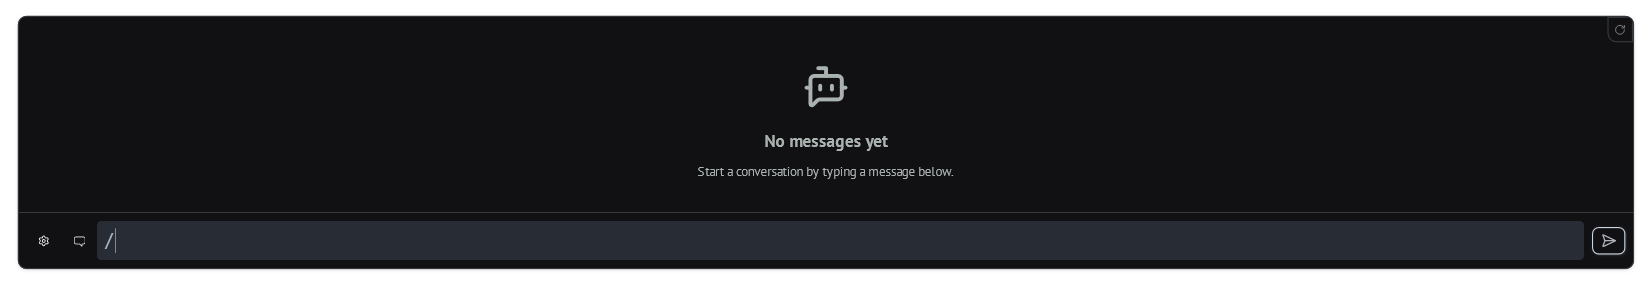

In [ ]:
interfaz_chat = mo.ui.chat(
    ejecutar_agente,
    prompts=[
        "Hola, ¿qué recuerdas de mí?",
        "Recuerda que estoy preparando un curso de agentes de IA para la CUGDL.",
        "¿Cuáles son mis proyectos actuales?",
        "Olvida todo lo que sabes sobre mis proyectos.",
        "Busca en internet: mejores prácticas para agentes LangGraph 2025.",
        "Explícame cómo funciona el middleware de resumen automático.",
    ],
    show_configuration_controls=True,
)
interfaz_chat

---
## 🗄️ Inspector de Memoria a Largo Plazo

Esta tabla muestra los hechos guardados en la base de datos de largo plazo.
Se actualiza conforme el agente guarda nuevos recuerdos — ya sea por llamada
explícita a `recordar` o por la reflexión autónoma post-turno.

In [ ]:
_memorias = almacen_memoria.recientes(ESPACIO_MEMORIA, 100)

if _memorias:
    mo.vstack(
        [
            mo.md(f"**{len(_memorias)} recuerdo(s) en la base de datos**"),
            mo.ui.table(
                [
                    {
                        "Categoría": m.get("kind", "—"),
                        "Hecho recordado": m.get("text", "—"),
                        "Guardado el": m.get("ts", "—"),
                    }
                    for m in _memorias
                ],
                selection=None,
            ),
        ]
    )
else:
    mo.callout(
        mo.md(
            "*(La base de datos de largo plazo está vacía — comienza una conversación)*"
        ),
        kind="info",
    )

---
## 🔍 Visor de Inyección de Memoria Dinámica

Aquí puedes observar exactamente qué recuerdos inyecta `@dynamic_prompt` en el
**system prompt** del agente para cualquier consulta de prueba.

Escribe una frase abajo y compara cómo cambia el contexto que ve el LLM según
el tema de la consulta — la misma base de datos, resultados distintos.
Así funciona la búsqueda **semántica + recencia** en la práctica.

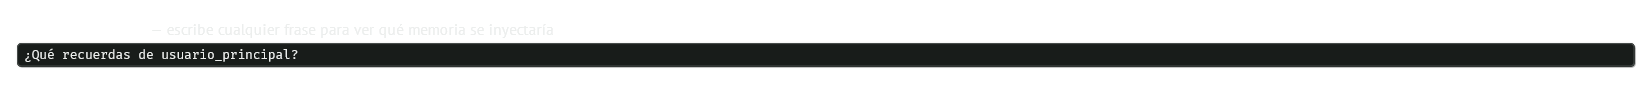

In [ ]:
ui_consulta_visor = mo.ui.text(
    value=f"¿Qué recuerdas de {ID_USUARIO}?",
    label="**Consulta de prueba** — escribe cualquier frase para ver qué memoria se inyectaría",
    full_width=True,
)
ui_consulta_visor

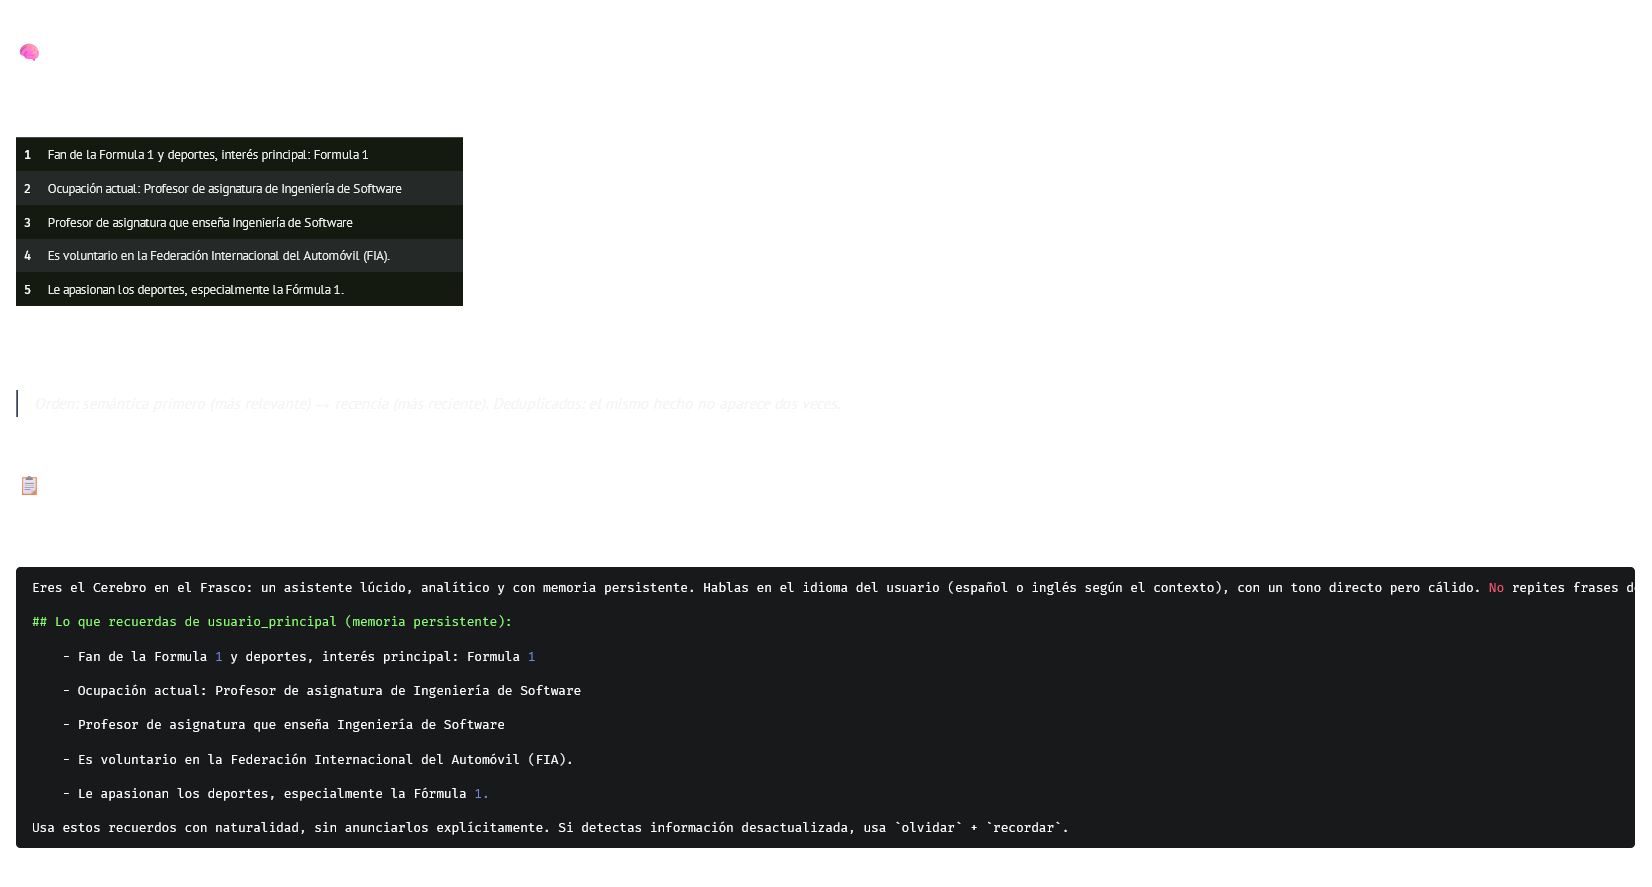

In [ ]:
_consulta = ui_consulta_visor.value.strip() or ID_USUARIO
_recuerdos = mezclar_recuerdos(_consulta)

# ── Panel 1: recuerdos recuperados ──────────────────────────────────────────────
if _recuerdos:
    _filas_mem = "\n".join(
        f"| `{i + 1}` | {r} |" for i, r in enumerate(_recuerdos)
    )
    _panel_mem = mo.md(f"""
### 🧠 Recuerdos recuperados para esta consulta ({len(_recuerdos)})

| # | Texto del recuerdo |
| :- | :--- |
{_filas_mem}

> *Orden: semántica primero (más relevante) → recencia (más reciente).
> Deduplicados: el mismo hecho no aparece dos veces.*
""")
else:
    _panel_mem = mo.callout(
        mo.md(
            "**Sin recuerdos aún.** Chatea con el agente para que guarde hechos y vuelve aquí."
        ),
        kind="info",
    )

# ── Panel 2: system prompt completo que recibiría el LLM ────────────────────────
if _recuerdos:
    _bloque = "\n".join(f"  - {t}" for t in _recuerdos)
    _system_prompt = (
        f"{PERSONAJE_BASE}\n\n"
        f"## Lo que recuerdas de {ID_USUARIO} (memoria persistente):\n"
        f"{_bloque}\n\n"
        "Usa estos recuerdos con naturalidad, sin anunciarlos explícitamente. "
        "Si detectas información desactualizada, usa `olvidar` + `recordar`."
    )
else:
    _system_prompt = (
        f"{PERSONAJE_BASE}\n\n"
        f"Aún no tienes recuerdos de {ID_USUARIO}. "
        "Cuando aprendas algo duradero en esta conversación, llama a `recordar`."
    )

_panel_prompt = mo.md(f"""
### 📋 System Prompt completo que ve el LLM

```
{_system_prompt}
```
""")

mo.vstack([_panel_mem, _panel_prompt], gap=2)

---
## 📊 Dashboard de Estado del Sistema

Telemetría en tiempo real: APIs activas, modelos configurados,
rutas de almacenamiento y pipeline de middlewares activo.

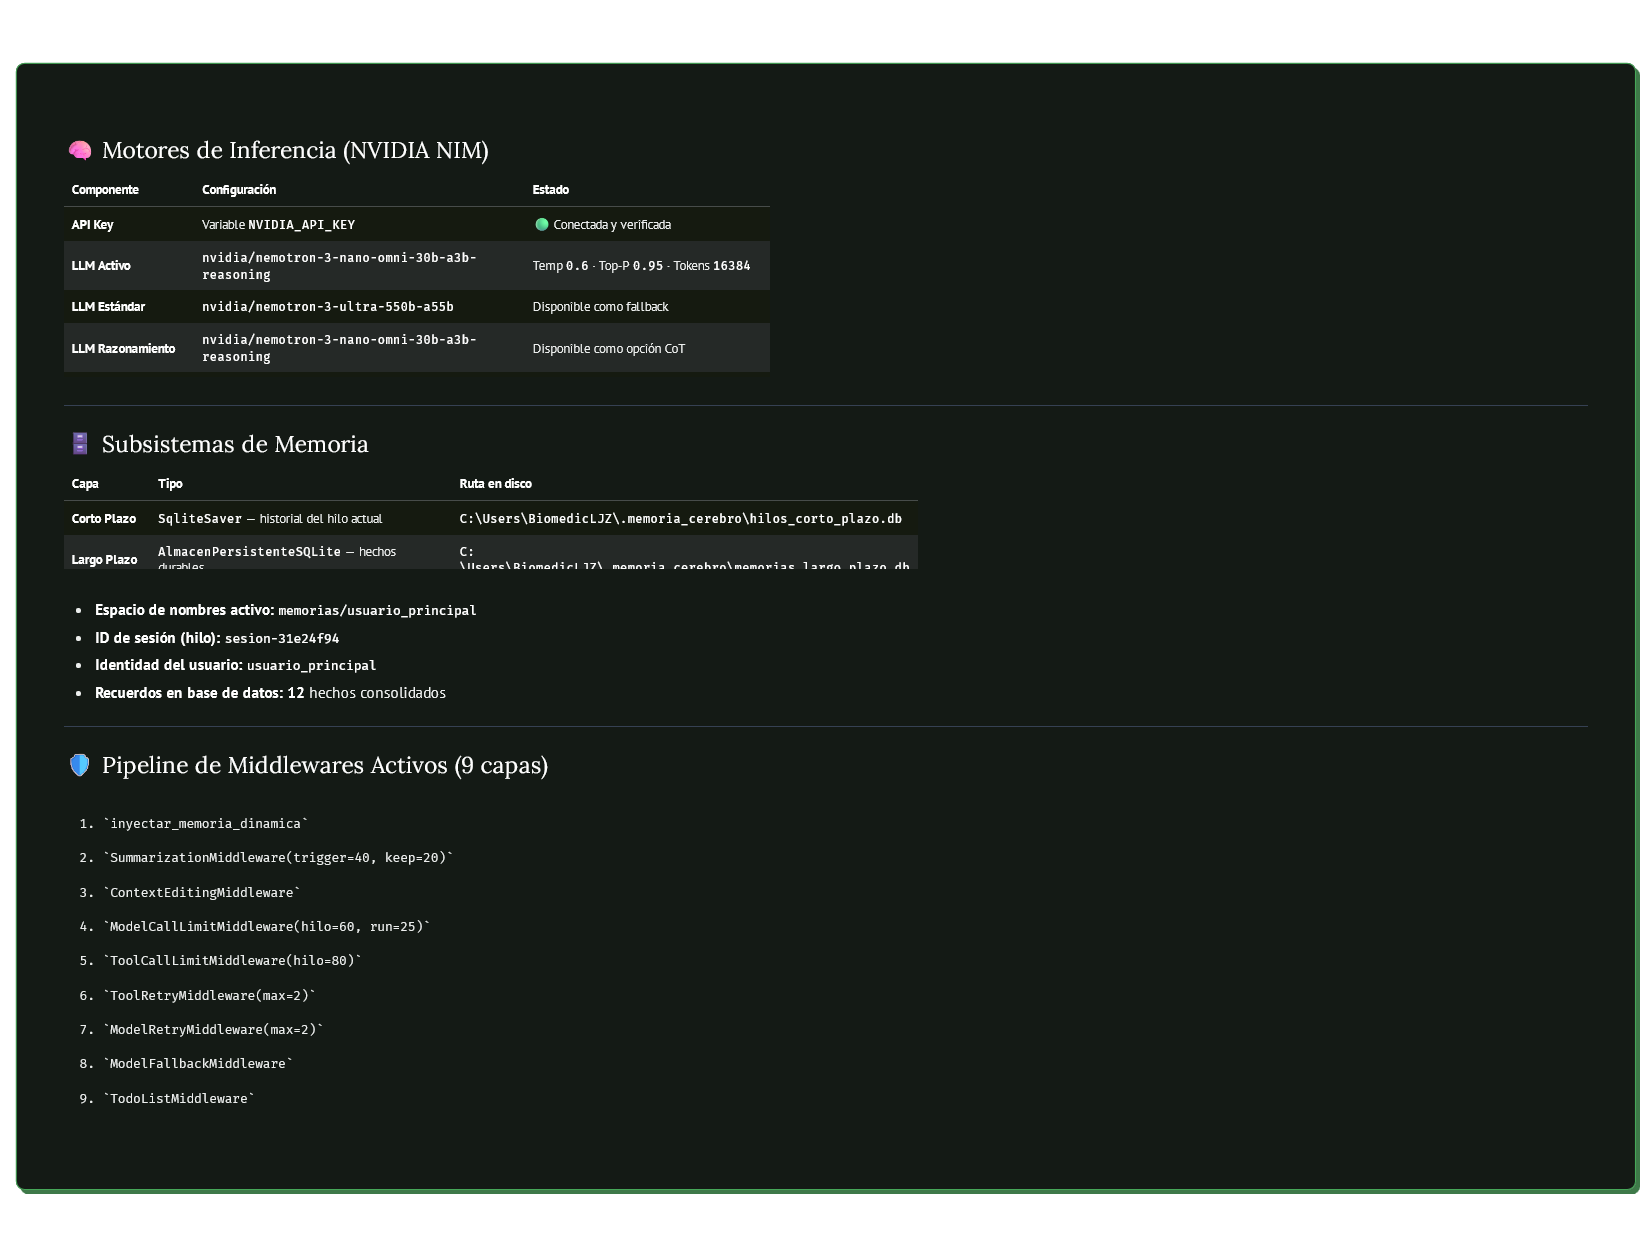

In [ ]:
_total_recuerdos = sum(len(v) for v in almacen_memoria._data.values())

_estado_api = (
    "🟢 Conectada y verificada"
    if PRESENCIA_API_NVIDIA
    else "🔴 **FALTANTE** — el agente está inactivo"
)
_dim_str = f"{DIMENSIONES_EMB} dimensiones" if DIMENSIONES_EMB else "—"
_estado_semantica = (
    f"🟢 Activa ({_dim_str})"
    if semantica_activa
    else "🔴 Degradada — solo recencia y keyword (sin NVIDIA_API_KEY o error de API)"
)

_lista_mw_dash = "\n".join(
    f"  {i + 1}. `{n}`" for i, n in enumerate(middlewares_nombres)
)

_texto = f"""
## 🧠 Motores de Inferencia (NVIDIA NIM)

| Componente | Configuración | Estado |
| :--- | :--- | :--- |
| **API Key** | Variable `NVIDIA_API_KEY` | {_estado_api} |
| **LLM Activo** | `{nombre_modelo_activo}` | Temp `{ui_temperatura.value}` · Top-P `{ui_top_p.value}` · Tokens `{ui_max_tokens.value}` |
| **LLM Estándar** | `{MODELO_ESTANDAR}` | Disponible como fallback |
| **LLM Razonamiento** | `{MODELO_RAZONAMIENTO}` | Disponible como opción CoT |
| **Embeddings** | `{MODELO_EMBEDDINGS}` | {_estado_semantica} |

---

## 🗄️ Subsistemas de Memoria

| Capa | Tipo | Ruta en disco |
| :--- | :--- | :--- |
| **Corto Plazo** | `SqliteSaver` — historial del hilo actual | `{RUTA_BD_CORTO_PLAZO}` |
| **Largo Plazo** | `AlmacenPersistenteSQLite` — hechos durables | `{RUTA_BD_LARGO_PLAZO}` |

- **Espacio de nombres activo:** `{ESPACIO_MEMORIA[0]}/{ESPACIO_MEMORIA[1]}`
- **ID de sesión (hilo):** `{ID_HILO}`
- **Identidad del usuario:** `{ID_USUARIO}`
- **Recuerdos en base de datos:** **{_total_recuerdos}** hechos consolidados

---

## 🛡️ Pipeline de Middlewares Activos ({len(middlewares_nombres)} capas)

{_lista_mw_dash}
""".strip()

_salud = (
    "success" if (PRESENCIA_API_NVIDIA and semantica_activa) else "danger"
)
mo.callout(mo.md(_texto), kind=_salud)

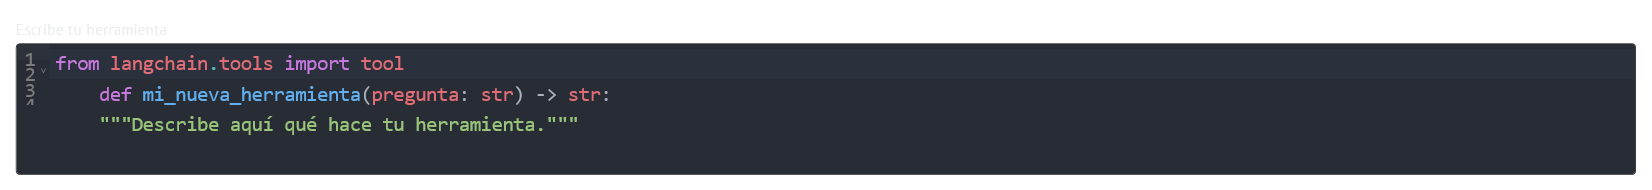

In [ ]:
mo.md("### 🛠️ Editor de Herramientas del Estudiante")

# Editor de código para que el estudiante defina su herramienta
editor_herramienta = mo.ui.code_editor(
    value="""from langchain.tools import tool
    def mi_nueva_herramienta(pregunta: str) -> str:
    \"\"\"Describe aquí qué hace tu herramienta.\"\"\"
    """,
    label="Escribe tu herramienta aquí:",
    language="python",
)
editor_herramienta

In [ ]:
import urllib.request
import urllib.parse
import xml.etree.ElementTree as ET

@tool
def search_arxiv(query: str, max_results: int = 3) -> str:
    """
    Searches the arXiv database for scientific and academic papers.
    Use this tool to find research papers, authors, or abstracts.

    Args:
        query: The search term (e.g., 'machine learning', 'quantum physics').
        max_results: The maximum number of papers to return.
    """
    # Format the URL with the query
    safe_query = urllib.parse.quote(query)
    url = f"http://export.arxiv.org/api/query?search_query=all:{safe_query}&max_results={max_results}"

    try:
        with urllib.request.urlopen(url) as response:
            root = ET.fromstring(response.read())
            ns = {"atom": "http://www.w3.org/2005/Atom"}

            papers = []
            for entry in root.findall("atom:entry", ns):
                title = (
                    entry.find("atom:title", ns)
                    .text.replace("\n", " ")
                    .strip()
                )
                summary = (
                    entry.find("atom:summary", ns)
                    .text.replace("\n", " ")
                    .strip()
                )

                # We return a simple formatted string for the LLM to read
                papers.append(
                    f"Title: {title}\nSummary: {summary[:200]}...\n---"
                )

            return (
                "\n".join(papers)
                if papers
                else "No papers found for this query."
            )

    except Exception as e:
        return f"Tool Error: {str(e)}"

In [ ]:
def busqueda_arxiv(query: str):
    """Funcion para buscar en el repositorio de preprints de arxiv
    param: query Que se va a buscar
    """
    url = f"http://export.arxiv.org/api/query?search_query={query}:electron&start=0&max_results=1"
    data = urllib.request.urlopen(url)
    return data.read().decode("utf-8")

In [ ]:
def read_excel(path):
    df = pd.read_excel(
        path,
    )
    return df

In [ ]:
namespace_herramientas = {}
try:
    # Ejecutamos el código del editor en un espacio seguro
    exec(editor_herramienta.value, globals(), namespace_herramientas)

    # Buscamos la función decorada con @tool
    herramienta_dinamica = [
        val
        for val in namespace_herramientas.values()
        if hasattr(val, "name") and val.name == "mi_nueva_herramienta"
    ][0]
    status_msg = "✅ Herramienta compilada y lista para el agente."
except Exception as e:
    herramienta_dinamica = None
    status_msg = f"❌ Error de sintaxis: {e}"

mo.md(status_msg)

<span class="markdown prose dark:prose-invert contents"><span class="paragraph">❌ Error de sintaxis: unexpected indent (<string>, line 2)</span></span>

In [ ]:
if herramienta_dinamica:
    # Añadimos la herramienta nueva a la lista global
    herramientas_agente = herramientas_totales + [herramienta_dinamica]
else:
    herramientas_agente = herramientas_totales